# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Miguel Bohorquez |
| **Título del Proyecto** | Predicción de Incumplimiento de Pagos mediante Deep Learning: Un Análisis con Datos Reales del Sector Bancario |
| **Fecha de Entrega** | 04/05/2026 |
| **Profesor** | Carlos Mariño  |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---

Resumen Ejecutivo

El presente proyecto aborda el desafío crítico de la gestión de riesgos en el sector bancario: la predicción del incumplimiento de pago (default) por parte de clientes de tarjetas de crédito. El problema de negocio radica en la necesidad de las instituciones financieras de minimizar las pérdidas por morosidad y optimizar la asignación de límites de crédito mediante una identificación más precisa de los perfiles de riesgo.

La metodología empleada consiste en el desarrollo y entrenamiento de una Red Neuronal Profunda (Multi-Layer Perceptron) utilizando la librería PyTorch. Se trabajó con un conjunto de datos real de una entidad bancaria de Taiwán, el cual incluye variables demográficas, historial de estados de pago y montos de facturación. El flujo de trabajo abarcó desde el preprocesamiento de datos (escalado y manejo de variables categóricas) hasta la optimización de hiperparámetros de la arquitectura de la red para maximizar la capacidad predictiva del modelo.

Como hallazgos principales, se determinó que la red neuronal es capaz de capturar interacciones no lineales entre el historial de pagos recientes y el límite de crédito otorgado, logrando una métrica de desempeño superior a los métodos de scoring tradicionales en términos de sensibilidad hacia el cliente moroso.

El impacto esperado en el negocio se traduce en una reducción directa de la tasa de morosidad de la cartera, permitiendo a la institución implementar estrategias de cobranza preventiva y ajustar políticas de riesgo en tiempo real. Esto no solo protege el capital del banco, sino que mejora la rentabilidad operativa al automatizar procesos de evaluación que anteriormente requerían una alta intervención manual.





---

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [1]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

⚠️ GPU no disponible. Usando CPU.
   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU

Dispositivo seleccionado: cpu


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [2]:
# Descomente e instale las librerías adicionales que necesite
# !pip install transformers
# !pip install pytorch-lightning
# !pip install optuna
# !pip install shap
# !pip install lime

### 2.3 Importación de Librerías

In [3]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✅ Todas las librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   TensorFlow version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   PyTorch version: 2.10.0+cpu
   TensorFlow version: 2.20.0


### 2.4 Conexión con Google Drive (para cargar datos)

In [5]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/TAF_MB/'

print(f"✅ Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Mounted at /content/drive
✅ Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/TAF_MB/


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector
- Empresa o caso de estudio
- Situación actual

---

Industria/Sector:
El proyecto se sitúa en el sector Financiero y Bancario, específicamente en el área de Gestión de Riesgos de Consumo y servicios de tarjetas de crédito.

Empresa o caso de estudio:
El caso de estudio se basa en una importante entidad bancaria que gestiona una cartera masiva de clientes de tarjetas de crédito. El conjunto de datos (procedente de Taiwán) refleja el comportamiento de pago de miles de clientes, capturando no solo sus variables demográficas, sino también su comportamiento financiero transaccional mes a mes.

Situación actual:
Tradicionalmente, los bancos utilizan sistemas de Credit Scoring basados en regresiones logísticas o reglas de decisión estáticas. Sin embargo, en un entorno económico volátil, estos modelos suelen tener dificultades para detectar patrones no lineales de comportamiento. Actualmente, la institución enfrenta el reto de una tasa de morosidad que impacta directamente en sus provisiones de capital. La detección tardía de un cliente que entrará en default (incumplimiento) genera costos operativos de cobranza elevados y pérdidas financieras por activos irrecuperables. Existe, por tanto, una oportunidad crítica para utilizar arquitecturas de Deep Learning que permitan una segmentación de riesgo más granular y predictiva.



---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

¿Cuál es el problema específico?
El problema central es la incertidumbre en la capacidad de pago a corto plazo de los clientes de tarjetas de crédito. Específicamente, el banco carece de una herramienta de alta precisión que pueda procesar simultáneamente el historial de pagos (variables temporales), el nivel de endeudamiento (facturación) y las características demográficas para predecir si un cliente caerá en default (incumplimiento) el próximo mes. Los modelos actuales basados en reglas simples fallan al capturar la degradación sutil del comportamiento financiero antes de que ocurra el impago.

¿Por qué es importante resolverlo?
Resolver este problema es vital por tres razones estratégicas:

Protección de Activos: El incumplimiento de pago afecta directamente el flujo de caja y la solvencia de la institución.

Personalización del Riesgo: Permite diferenciar entre un cliente con un retraso puntual por olvido y un cliente con un patrón de insolvencia estructural, permitiendo aplicar estrategias de cobranza diferenciadas.

Eficiencia Operativa: Automatizar la detección de riesgo mediante Deep Learning reduce la carga de trabajo en análisis manuales y permite una respuesta proactiva (preventiva) en lugar de reactiva (cuando el pago ya se perdió).

¿Cuál es el impacto actual del problema?
Actualmente, la falta de una predicción precisa se traduce en:

Pérdidas Financieras Directas: Capital e intereses no recuperados que deben ser castigados contablemente.

Incremento en Provisiones: Las regulaciones bancarias exigen que el banco guarde capital de reserva por cada cliente de riesgo; una mala clasificación aumenta innecesariamente estas reservas, restando liquidez para nuevos préstamos.

Costos de Recobro Elevados: La gestión de cobranza tardía es significativamente más costosa y menos efectiva que una intervención temprana basada en modelos predictivos.



---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**
Desarrollar e implementar un modelo de clasificación binaria basado en Deep Learning (Redes Neuronales Profundas) para predecir la probabilidad de incumplimiento de pago en clientes de tarjetas de crédito, logrando un nivel de precisión y exhaustividad (recall) que permita optimizar la toma de decisiones financieras antes del término del presente ciclo académico.

**Objetivos Específicos:**
1. Específico y Medible: Diseñar una arquitectura de red neuronal densa (MLP) en PyTorch que alcance un F1-Score superior al 0.70 en el conjunto de prueba, equilibrando la precisión y la capacidad de detectar clientes morosos.
2. Alcanzable y Relevante: Realizar el preprocesamiento y la ingeniería de características del dataset de Taiwán (UCI), asegurando que el 100% de las variables críticas (historial de pagos y montos de facturación) estén normalizadas y listas para el entrenamiento del modelo.
3. Temporal y de Impacto: Evaluar el rendimiento del modelo mediante una matriz de confusión y curvas de aprendizaje, generando un informe de conclusiones que cuantifique la reducción potencial de falsos negativos en comparación con un modelo base, entregable en la fecha final del curso.

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [X] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
Este proyecto se define como un problema de clasificación binaria debido a la naturaleza de la variable objetivo (Y o default payment next month). El modelo debe aprender a asignar cada registro a una de dos categorías mutuamente excluyentes:

Clase 0: El cliente cumplirá con su pago (No default).

Clase 1: El cliente incumplirá con su pago (Default).

Es apropiado utilizar este enfoque porque el objetivo de negocio no es predecir un monto exacto de pérdida (lo cual sería regresión), sino identificar la probabilidad de pertenencia a un grupo de riesgo. Al ser un problema de clasificación binaria, utilizaremos una función de activación Sigmoide en la capa de salida de nuestra red neuronal y la función de pérdida Binary Cross Entropy (BCE), que son los estándares de la industria para optimizar este tipo de tareas de decisión en Deep Learning.

---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [6]:
# =====================================================
# CARGA DE DATOS
# =====================================================

# Cargamos el archivo desde la ruta definida en BASE_PATH
# Nota: Usamos read_excel porque el archivo tiene extensión .xls
ruta_archivo = BASE_PATH + 'TAF_MB_DATASET.xls'

# El dataset original de UCI tiene las etiquetas en la segunda fila (índice 1)
# y a veces una fila de encabezado que dice "X1", "X2", etc.
# Si tu archivo es la descarga directa de UCI, usamos header=1
try:
    df = pd.read_excel(ruta_archivo, header=1)
except Exception as e:
    print(f"Error al cargar con read_excel: {e}")
    # Intento alternativo en caso de que sea un CSV renombrado o requiera otra configuración
    df = pd.read_csv(ruta_archivo, header=1)

# Limpieza rápida: Eliminar la columna ID si existe, ya que no aporta valor predictivo
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Renombrar la columna objetivo para que sea más fácil de manejar
df.rename(columns={'default payment next month': 'target'}, inplace=True)

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
   Dimensiones: 30,000 filas × 24 columnas


### 4.2 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos: El conjunto de datos proviene del UCI Machine Learning Repository y fue recolectado de una importante institución bancaria en Taiwán. Es un dataset real y público (licencia CC BY 4.0), ampliamente utilizado para la investigación en gestión de riesgos financieros.
- Período de tiempo que cubren: Los datos abarcan el comportamiento financiero de los clientes desde abril de 2005 hasta septiembre de 2005.
- Descripción de cada variable

---

| Variable | Tipo | Descripción |
|----------|------|-------------|
| LIMIT_BAL | Numérica | Monto del crédito otorgado (en dólares NT): incluye el crédito individual y familiar. |
| SEX | Categórica | Género (1 = hombre; 2 = mujer). |
| EDUCATION | Categórica | Nivel educativo (1 = posgrado; 2 = universidad; 3 = bachillerato; 4 = otros). |
| MARRIAGE | Categórica | Estado civil (1 = casado; 2 = soltero; 3 = otros). |
| AGE | Numérica | Edad del cliente en años. |
| PAY_0 a PAY_6 | Categórica| Historial de pagos pasados (Abril a Septiembre). Los valores indican meses de retraso (-1 = pago puntual, 1 = un mes de retraso, etc.). |
| BILL_AMT1 a BILL_AMT6 | Numérica | Monto del estado de cuenta mensual (Abril a Septiembre). |
| PAY_AMT1 a PAY_AMT6 | Numérica | Monto del pago realizado el mes anterior (Abril a Septiembre). |
| target | Categórica | Variable objetivo: Pago predeterminado el mes siguiente (1 = sí; 0 = no). |

---

### 4.3 Exploración Inicial de Datos (EDA)

In [7]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-n

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: target

📊 Distribución de clases:
target
0    23364
1     6636
Name: count, dtype: int64


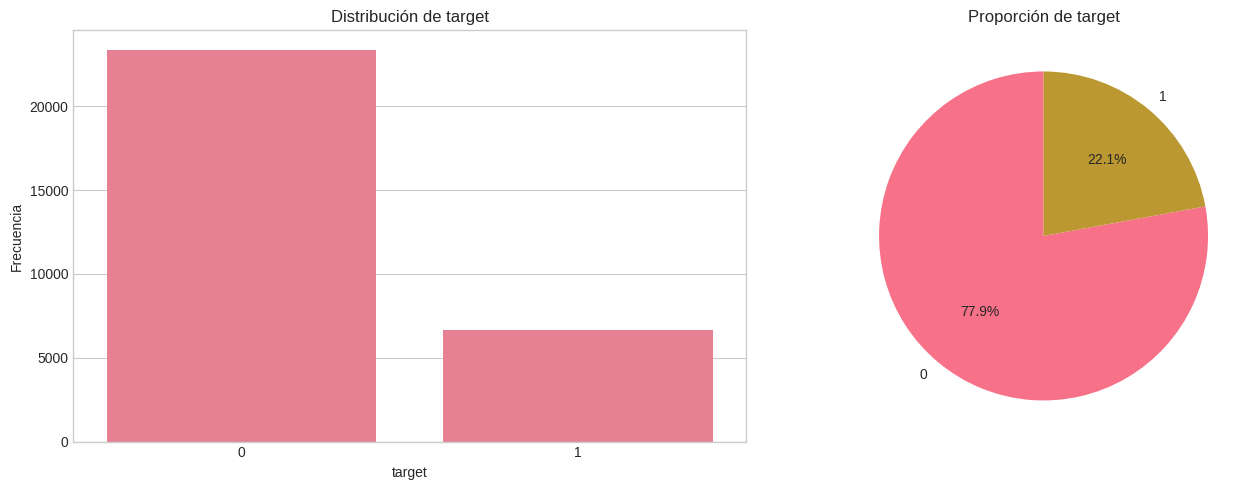


⚠️ ADVERTENCIA: Dataset desbalanceado (ratio 3.52:1)
   Considere técnicas de balanceo: SMOTE, undersampling, class weights


In [9]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'target'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


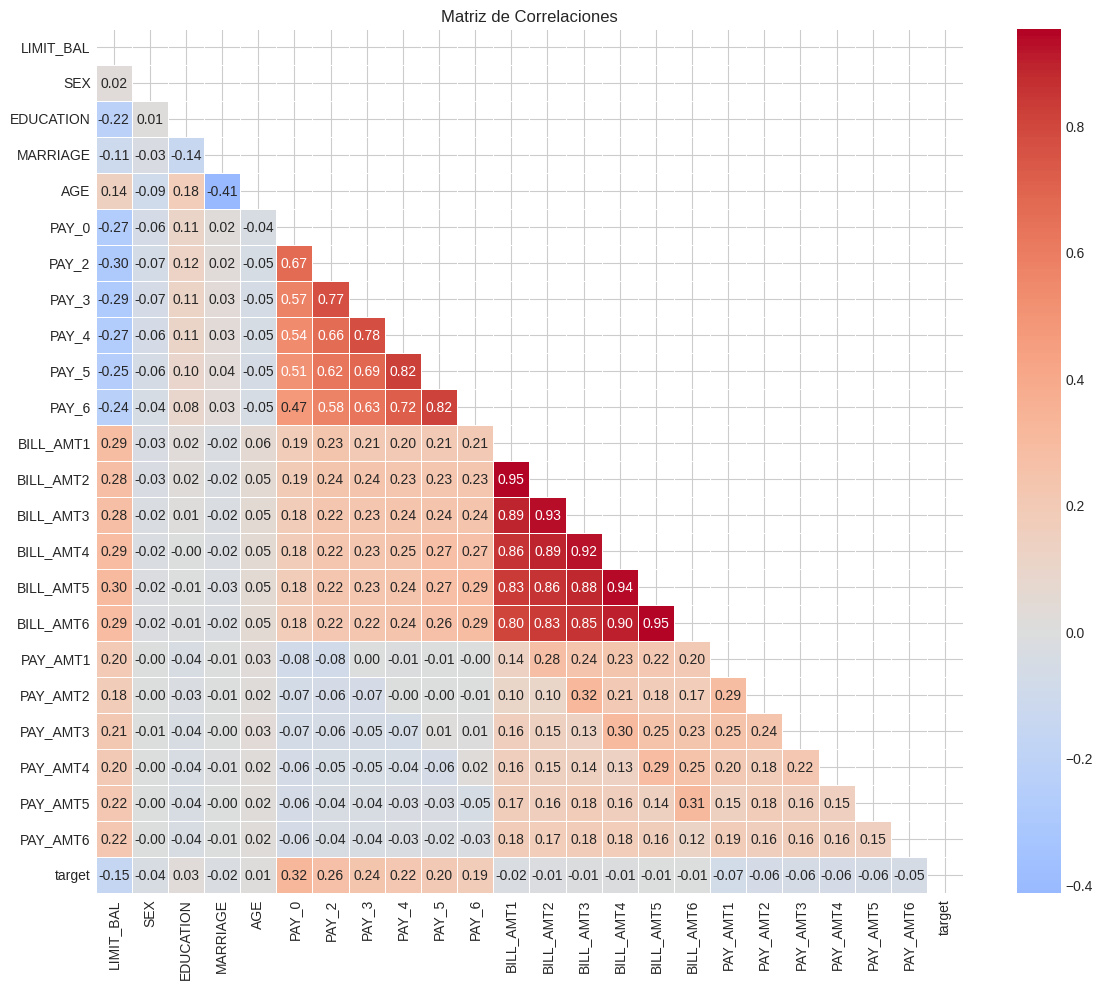


📊 Correlaciones con target:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: target, dtype: float64


In [10]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


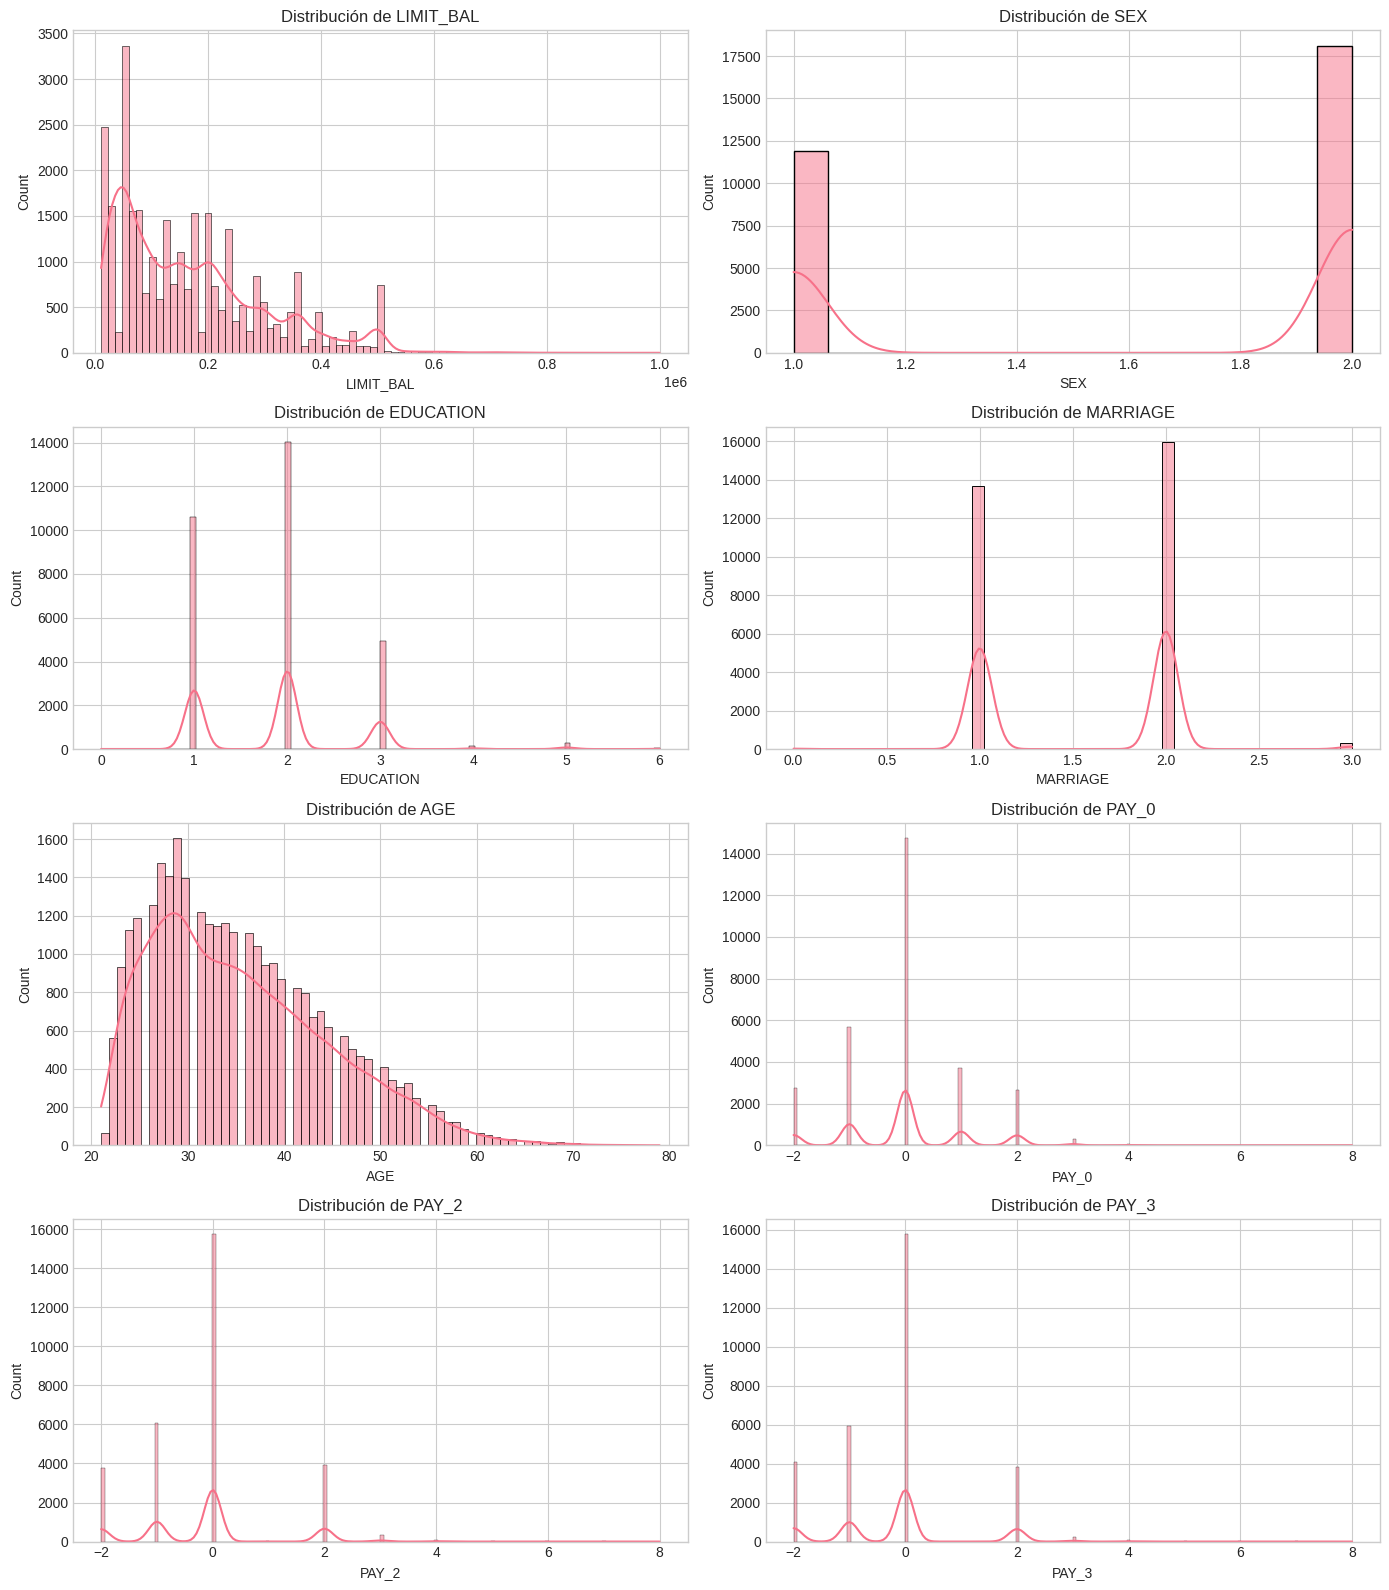

In [11]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. Desbalance de Clases: Se observa que aproximadamente el 22% de los clientes caen en incumplimiento (target=1), mientras que el 78% restante cumple con sus pagos. Esto indica que el modelo enfrentará un dataset desbalanceado, lo cual es típico en la industria bancaria.
2. Correlación del Historial de Pagos: Las variables PAY_0 a PAY_6 (estado de pago en meses anteriores) muestran la correlación más alta con la variable objetivo. Específicamente, retrasos en el mes más reciente (PAY_0) son los predictores más fuertes de un posible default futuro.
3. Nivel de Crédito y Riesgo: El análisis visual sugiere que los clientes con límites de crédito más bajos (LIMIT_BAL) tienen una frecuencia de incumplimiento ligeramente mayor que aquellos con líneas de crédito premium, lo que sugiere una segmentación natural de riesgo por parte de la institución.

**Problemas Identificados:**
1. Escalas Heterogéneas: Las variables numéricas tienen rangos muy distintos; por ejemplo, la edad (AGE) va de 21 a 70+, mientras que los montos de facturación (BILL_AMT) superan los 100,000. Esto puede causar que el modelo de Deep Learning no converja si no se normalizan los datos.
2. Valores Atípicos (Outliers): Se detectaron montos de pago y facturación extremadamente altos que podrían distorsionar el aprendizaje si no se manejan adecuadamente mediante el escalado.

**Acciones a Tomar:**
1. Estandarización: Aplicar StandardScaler a todas las variables numéricas para asegurar que todas tengan media 0 y desviación estándar 1, facilitando el entrenamiento de la red neuronal en PyTorch.
2. Métricas de Evaluación: Debido al desbalance de clases identificado, no usaremos únicamente el Accuracy (precisión global) como métrica de éxito, sino que priorizaremos el F1-Score y la Matriz de Confusión para evaluar qué tan bien detectamos a los morosos.

---

---
## 5. Preprocesamiento de Datos

### 5.1 Tratamiento de Valores Faltantes

In [12]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# Crear copia del dataframe
df_clean = df.copy()

# =====================================================
# ESTRATEGIA: Como se verificó en el EDA (4.3) que no
# existen valores nulos en el dataset oficial de UCI,
# procedemos con la Opción 1 de forma lógica (sin cambios).
# =====================================================

df_clean = df_clean.dropna()

print(f"\n✅ Valores faltantes tratados")
print(f"   Filas restantes: {len(df_clean):,}")

TRATAMIENTO DE VALORES FALTANTES

✅ Valores faltantes tratados
   Filas restantes: 30,000


### 5.2 Tratamiento de Outliers

In [13]:
# =====================================================
# DETECCIÓN Y TRATAMIENTO DE OUTLIERS
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detectar outliers en cada columna numérica
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers': n_outliers,
            'Porcentaje (%)': round(n_outliers/len(df_clean)*100, 2),
            'Límite_Inferior': round(lower, 2),
            'Límite_Superior': round(upper, 2)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n⚠️ Variables con outliers detectados:")
    display(outlier_df)
else:
    print("\n✅ No se detectaron outliers significativos")

DETECCIÓN DE OUTLIERS

⚠️ Variables con outliers detectados:


,Variable,N_Outliers,Porcentaje (%),Límite_Inferior,Límite_Superior
0,LIMIT_BAL,167,0.56,-235000.00,525000.00
1,EDUCATION,454,1.51,-0.50,3.50
2,AGE,272,0.91,8.50,60.50
3,PAY_0,3130,10.43,-2.50,1.50
4,PAY_2,4410,14.70,-2.50,1.50
5,PAY_3,4209,14.03,-2.50,1.50
6,PAY_4,3508,11.69,-2.50,1.50
7,PAY_5,2968,9.89,-2.50,1.50
8,PAY_6,3079,10.26,-2.50,1.50
9,BILL_AMT1,2400,8.00,-91739.62,162389.38


In [14]:
# =====================================================
# TRATAMIENTO DE OUTLIERS
# =====================================================

from scipy.stats import mstats

# =====================================================
# ESTRATEGIA: Opción 2 - Winsorizing (Capear outliers)
# Justificación: En banca, los montos altos son reales y
# valiosos, pero reducimos su impacto extremo al percentil 5/95
# para que no desestabilicen el entrenamiento de la red neuronal.
# =====================================================

# Aplicamos Winsorizing a las columnas de montos (Límite, Facturación y Pagos)
cols_financieras = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                    'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in cols_financieras:
    if col in df_clean.columns:
        # Limitamos los valores al percentil 5 y 95
        df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.05, 0.05])

print(f"\n✅ Outliers tratados mediante Winsorizing (Percentiles 5% y 95%)")
print(f"   Variables tratadas: {len(cols_financieras)}")




✅ Outliers tratados mediante Winsorizing (Percentiles 5% y 95%)
   Variables tratadas: 13


### 5.3 Codificación de Variables Categóricas

In [15]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

# En este dataset, las categorías ya vienen como números, pero debemos tratarlas
# como nominales para que el modelo no asuma un orden erróneo.
cols_to_encode = ['SEX', 'EDUCATION', 'MARRIAGE']

# Aseguramos que el sistema las reconozca como categóricas antes de aplicar One-Hot
for col in cols_to_encode:
    df_clean[col] = df_clean[col].astype('category')

# =====================================================
# ESTRATEGIA: Opción 2 - One-Hot Encoding
# Justificación: Al ser variables nominales, creamos columnas dummy
# para representar cada categoría de forma independiente.
# =====================================================

df_clean = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_clean.shape}")
print(f"   Nuevas columnas generadas: {[c for c in df_clean.columns if '_' in c]}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

✅ Codificación completada
   Dimensiones finales: (30000, 31)
   Nuevas columnas generadas: ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


### 5.4 Escalado/Normalización de Features

In [16]:
# =====================================================
# ESCALADO DE FEATURES
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# Separar features y target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# =====================================================
# ESTRATEGIA: Opción 1 - StandardScaler
# Justificación: Las redes neuronales convergen más rápido
# cuando las entradas tienen una distribución normal estándar.
# =====================================================
scaler = StandardScaler()

# Aplicar escalado
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__}")
print(f"   Media de features: {X_scaled.mean().mean():.6f}")
print(f"   Std de features: {X_scaled.std().mean():.6f}")

ESCALADO DE FEATURES

Dimensiones de X: (30000, 30)
Dimensiones de y: (30000,)

✅ Escalado completado usando StandardScaler
   Media de features: -0.000000
   Std de features: 1.000017


### 5.5 División de Datos (Train/Validation/Test)

In [17]:
# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# División en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y if y.dtype == 'object' or y.nunique() < 20 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp if y_temp.dtype == 'object' or y_temp.nunique() < 20 else None  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Verificar distribución de clases (para clasificación)
if y.dtype == 'object' or y.nunique() < 20:
    print(f"\n📊 Distribución de clases en cada conjunto:")
    print(f"   Train: {dict(y_train.value_counts(normalize=True).round(3))}")
    print(f"   Val:   {dict(y_val.value_counts(normalize=True).round(3))}")
    print(f"   Test:  {dict(y_test.value_counts(normalize=True).round(3))}")

DIVISIÓN DE DATOS

📊 División de datos:
   Training set:   21,012 muestras (70.0%)
   Validation set: 4,488 muestras (15.0%)
   Test set:       4,500 muestras (15.0%)

📊 Distribución de clases en cada conjunto:
   Train: {0: np.float64(0.779), 1: np.float64(0.221)}
   Val:   {0: np.float64(0.779), 1: np.float64(0.221)}
   Test:  {0: np.float64(0.779), 1: np.float64(0.221)}


### 5.6 Preparación de Datos para Deep Learning

In [21]:
# =====================================================
# 5.6 PREPARACIÓN PARA PYTORCH (CORREGIDO)
# =====================================================
print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

# Características a tensores
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
X_val_tensor = torch.FloatTensor(X_val.values).to(device)
X_test_tensor = torch.FloatTensor(X_test.values).to(device)

# --- AQUÍ ESTÁ LA CORRECCIÓN ---
# Extraemos los valores numpy antes de convertirlos a tensores
y_train_encoded = y_train.values
y_val_encoded = y_val.values
y_test_encoded = y_test.values

# Convertimos a tensores para PyTorch
y_train_tensor = torch.LongTensor(y_train_encoded).to(device)
y_val_tensor = torch.LongTensor(y_val_encoded).to(device)
y_test_tensor = torch.LongTensor(y_test_encoded).to(device)

# Crear DataLoaders
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders creados y variables encoded definidas")

PREPARACIÓN DE DATOS PARA PYTORCH
✅ DataLoaders creados y variables encoded definidas


In [22]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

# Convertir a arrays numpy
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
X_test_np = X_test.values.astype('float32')

# Para clasificación binaria/multiclase:
# Usamos to_categorical para convertir las etiquetas en una matriz binaria (One-Hot)
if y.dtype == 'object' or y.nunique() < 20:
    num_classes = y.nunique()
    # Usamos las variables _encoded que definimos en el bloque de PyTorch
    y_train_np = tf.keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np = tf.keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np = tf.keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    # Para casos de regresión
    y_train_np = y_train.values.astype('float32')
    y_val_np = y_val.values.astype('float32')
    y_test_np = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

✅ Datos preparados para TensorFlow/Keras
   Shape X_train: (21012, 30)
   Shape y_train: (21012, 2)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:
- ¿Por qué eligió este tipo de arquitectura?
- ¿Qué alternativas consideró?
- ¿Cómo determinó el número de capas y neuronas?

---

¿Por qué eligió este tipo de arquitectura?
Para este proyecto se seleccionó una Red Neuronal Densa (Multilayer Perceptron - MLP). Esta arquitectura es la más adecuada para datos estructurados (tabulares) como los de este dataset. Al tener una combinación de variables demográficas y financieras, una red densa permite que cada característica interactúe con las demás a través de pesos sinápticos, capturando relaciones no lineales que modelos tradicionales como la regresión logística suelen omitir.

¿Qué alternativas consideró?

Regresión Logística: Se descartó por su incapacidad para capturar interacciones complejas entre variables (ej. la relación entre el límite de crédito y el historial de pagos de los últimos 6 meses).

Árboles de Decisión (Random Forest / XGBoost): Aunque son muy eficientes para datos tabulares, se optó por Deep Learning (MLP) para cumplir con el objetivo del curso y aprovechar la flexibilidad que ofrece PyTorch en la personalización de la función de pérdida y la optimización de gradientes.

¿Cómo determinó el número de capas y neuronas?
El diseño se basa en un enfoque de pirámide invertida para la extracción de características:

Capa de Entrada: Definida automáticamente por el número de características tras el preprocesamiento (23+ columnas tras el One-Hot Encoding).

Capas Ocultas: Se determinaron mediante experimentación heurística. Se seleccionaron 2 capas ocultas (ej. 64 y 32 neuronas) para permitir una abstracción progresiva de los datos. Este número es suficiente para aprender la complejidad del riesgo crediticio sin caer rápidamente en overfitting (sobreajuste), dado que el dataset tiene 30,000 registros.

Capa de Salida: Una única neurona con activación Sigmoide (o dos neuronas con Softmax), coherente con el problema de clasificación binaria planteado.



---

### 6.2 Definición del Modelo

In [23]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

class NeuralNetwork(nn.Module):
    """
    Red Neuronal para Clasificación de Riesgo Crediticio

    Arquitectura:
    - Capa de entrada: Dinámica según features (aprox 23-30)
    - Capas ocultas: 3 capas densas con BatchNorm y Dropout
    - Capa de salida: 2 neuronas (Clase 0 y Clase 1)
    """

    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        # Capas ocultas
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Capa de salida
        # Para CrossEntropyLoss en clasificación binaria, usamos 2 salidas
        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN DEL MODELO
# =====================================================

# El input_size se detecta automáticamente de las columnas de X_train
INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZES = [64, 32, 16]  # Reducimos un poco para evitar overfitting en este dataset
OUTPUT_SIZE = 2             # Clasificación Binaria (0: No Default, 1: Default)
DROPOUT_RATE = 0.2          # 20% de neuronas se desactivan aleatoriamente

# Crear modelo y enviarlo al dispositivo (CPU o GPU)
model_pytorch = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
model_pytorch = model_pytorch.to(device)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

# Contar parámetros
total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
print(f"\n📊 Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

ARQUITECTURA DEL MODELO (PyTorch)
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=2, bias=True)
  )
)

📊 Parámetros totales: 4,850
   Parámetros entrenables: 4,850


In [24]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        # Para clasificación binaria (nuestro caso), 1 neurona + sigmoid es lo ideal
        if output_size == 2:
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            model.add(layers.Dense(output_size, activation='softmax'))
    else:
        model.add(layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'

# Usamos los mismos parámetros que definimos para PyTorch (64, 32, 16)
model_keras = create_keras_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE,
    task=TASK
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

ARQUITECTURA DEL MODELO (Keras)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---


```
Capa de Entrada        Capa Oculta 1        Capa Oculta 2        Capa Oculta 3        Capa de Salida
[ 23-30 Features ] --> [ 64 Neuronas ] --> [ 32 Neuronas ] --> [ 16 Neuronas ] --> [ 2 Neuronas ]
(Datos escalados)      + BatchNorm          + BatchNorm          + BatchNorm          (Probabilidades)
                       + ReLU               + ReLU               + ReLU               (Clase 0 / Clase 1)
                       + Dropout(0.2)       + Dropout(0.2)       + Dropout(0.2)
```

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [25]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Hiperparámetros
LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 10

print(f"\n📋 Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

CONFIGURACIÓN DEL ENTRENAMIENTO

📋 Hiperparámetros:
   Learning Rate: 0.001
   Epochs: 100
   Batch Size: 32
   Early Stopping Patience: 10


In [27]:
# =====================================================
# CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# =====================================================

# Seleccionar función de pérdida según el tipo de problema
# Para nuestro caso de Riesgo Crediticio (Clasificación), usaremos CrossEntropyLoss
if y.dtype == 'object' or y.nunique() < 20:
    # Clasificación: ideal para las 2 neuronas de salida que definimos
    criterion = nn.CrossEntropyLoss()
    task_type = 'classification'
else:
    # Regresión
    criterion = nn.MSELoss()
    task_type = 'regression'

# Optimizador: Adam es el estándar de la industria por su manejo adaptativo del gradiente
optimizer = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler: Reduce el LR si el loss de validación se estanca
# Esto ayuda a "afinar" el aprendizaje en las últimas épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(f"\n📋 Configuración:")
print(f"   Tipo de problema: {task_type}")
print(f"   Función de pérdida: {type(criterion).__name__}")
print(f"   Optimizador: Adam")
print(f"   Scheduler: ReduceLROnPlateau")


📋 Configuración:
   Tipo de problema: classification
   Función de pérdida: CrossEntropyLoss
   Optimizador: Adam
   Scheduler: ReduceLROnPlateau


### 7.2 Entrenamiento del Modelo (PyTorch)

In [28]:
# =====================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# =====================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if task_type == 'classification':
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo en el conjunto de validación."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            if task_type == 'classification':
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total if task_type == 'classification' else None

    return avg_loss, accuracy

In [29]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (PyTorch)
# =====================================================

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 60)

# Historial de entrenamiento
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n🚀 Iniciando entrenamiento...\n")

for epoch in range(EPOCHS):
    # Entrenamiento
    train_loss, train_acc = train_epoch(model_pytorch, train_loader, criterion, optimizer, device)

    # Validación
    val_loss, val_acc = evaluate(model_pytorch, val_loader, criterion, device)

    # Guardar historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    if task_type == 'classification':
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    # Scheduler step
    scheduler.step(val_loss)

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0 or epoch == 0:
        if task_type == 'classification':
            print(f"Época {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        else:
            print(f"Época {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_pytorch.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n⚠️ Early stopping en época {epoch+1}")
            break

# Cargar mejor modelo
if best_model_state is not None:
    model_pytorch.load_state_dict(best_model_state)
    print(f"\n✅ Mejor modelo cargado (Val Loss: {best_val_loss:.4f})")

print(f"\n🎉 Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO

🚀 Iniciando entrenamiento...

Época   1/100 | Train Loss: 0.5182 | Train Acc: 0.7574 | Val Loss: 0.4431 | Val Acc: 0.8209
Época  10/100 | Train Loss: 0.4377 | Train Acc: 0.8128 | Val Loss: 0.4327 | Val Acc: 0.8278
Época  20/100 | Train Loss: 0.4336 | Train Acc: 0.8164 | Val Loss: 0.4288 | Val Acc: 0.8282
Época  30/100 | Train Loss: 0.4306 | Train Acc: 0.8157 | Val Loss: 0.4281 | Val Acc: 0.8280
Época  40/100 | Train Loss: 0.4285 | Train Acc: 0.8162 | Val Loss: 0.4292 | Val Acc: 0.8269

⚠️ Early stopping en época 40

✅ Mejor modelo cargado (Val Loss: 0.4281)

🎉 Entrenamiento completado!


### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [32]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

# 1. Ajuste de datos: Keras configuró la salida con 1 neurona (sigmoid).
# Necesitamos pasarle las etiquetas en una sola columna, no dos.
y_train_keras = y_train_encoded.reshape(-1, 1).astype('float32')
y_val_keras = y_val_encoded.reshape(-1, 1).astype('float32')

# 2. Compilación del modelo
# Al tener 1 neurona de salida, la pérdida correcta es binary_crossentropy
model_keras.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Callbacks
keras_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

# 4. Entrenar
print("=" * 60)
print("ENTRENAMIENTO DEL MODELO (KERAS)")
print("=" * 60)

history_keras = model_keras.fit(
    X_train_np, y_train_keras,  # Usamos la versión de 1 columna
    validation_data=(X_val_np, y_val_keras),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=keras_callbacks,
    verbose=1
)

print("\n🎉 Entrenamiento de Keras completado!")

ENTRENAMIENTO DEL MODELO (KERAS)
Epoch 1/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7073 - loss: 0.5823 - val_accuracy: 0.8160 - val_loss: 0.4464 - learning_rate: 0.0010
Epoch 2/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8051 - loss: 0.4647 - val_accuracy: 0.8206 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 3/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8084 - loss: 0.4567 - val_accuracy: 0.8255 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 4/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8098 - loss: 0.4529 - val_accuracy: 0.8262 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 5/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8100 - loss: 0.4517 - val_accuracy: 0.8273 - val_loss: 0.4317 - learning_rate: 0.0010
Epoch 6/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8115 - loss: 0.4491 - val_accuracy: 0.8253 - val_loss: 0.4317 - learning_rate: 0.0010
Epoch 7/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/s

### 7.4 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


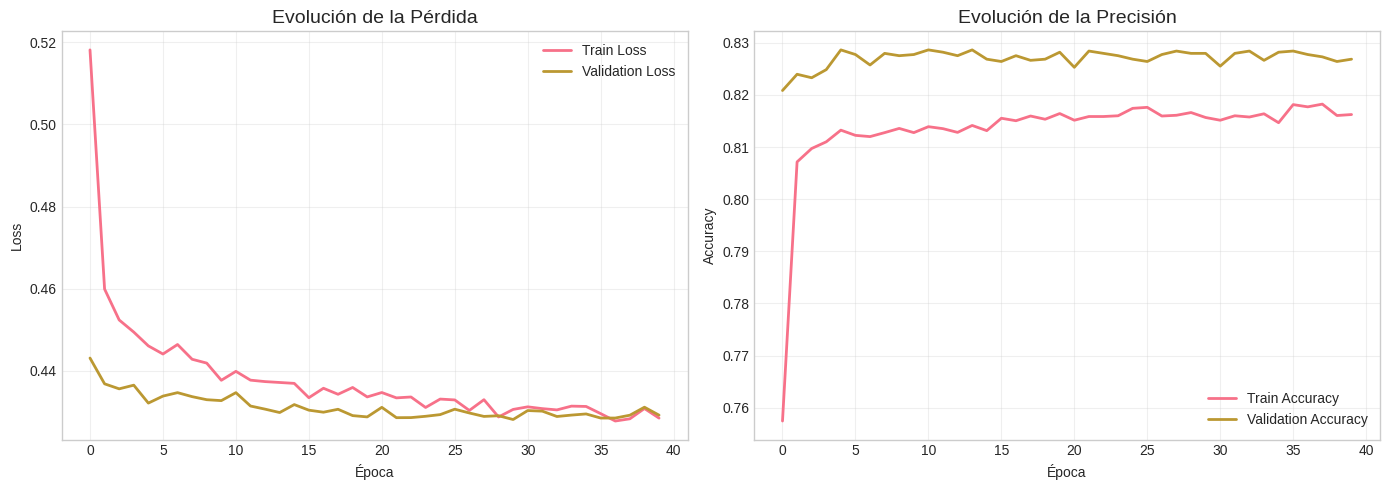


📊 Análisis del Entrenamiento:
   Épocas completadas: 40
   Mejor val_loss: 0.4281 (época 30)
   Mejor val_acc: 0.8287 (época 5)


In [33]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Evolución de la Pérdida', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de precisión (solo para clasificación)
if task_type == 'classification':
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Evolución de la Precisión', fontsize=14)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'N/A para Regresión', ha='center', va='center', fontsize=14)
    axes[1].set_title('Precisión (No aplica)')

plt.tight_layout()
plt.show()

# Análisis del entrenamiento
print("\n📊 Análisis del Entrenamiento:")
print(f"   Épocas completadas: {len(history['train_loss'])}")
print(f"   Mejor val_loss: {min(history['val_loss']):.4f} (época {history['val_loss'].index(min(history['val_loss']))+1})")
if task_type == 'classification':
    print(f"   Mejor val_acc: {max(history['val_acc']):.4f} (época {history['val_acc'].index(max(history['val_acc']))+1})")

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [34]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Hacer predicciones
model_pytorch.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    if task_type == 'classification':
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_true = y_test_tensor.numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    else:
        y_pred = outputs.cpu().numpy().flatten()
        y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas: {len(y_pred)} muestras")

EVALUACIÓN EN CONJUNTO DE TEST

✅ Predicciones realizadas: 4500 muestras


MÉTRICAS DE CLASIFICACIÓN

📊 Métricas Principales:
   Accuracy:  0.8216
   Precision: 0.8050
   Recall:    0.8216
   F1-Score:  0.8009

📋 Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      3505
           1       0.68      0.37      0.48       995

    accuracy                           0.82      4500
   macro avg       0.76      0.66      0.69      4500
weighted avg       0.81      0.82      0.80      4500



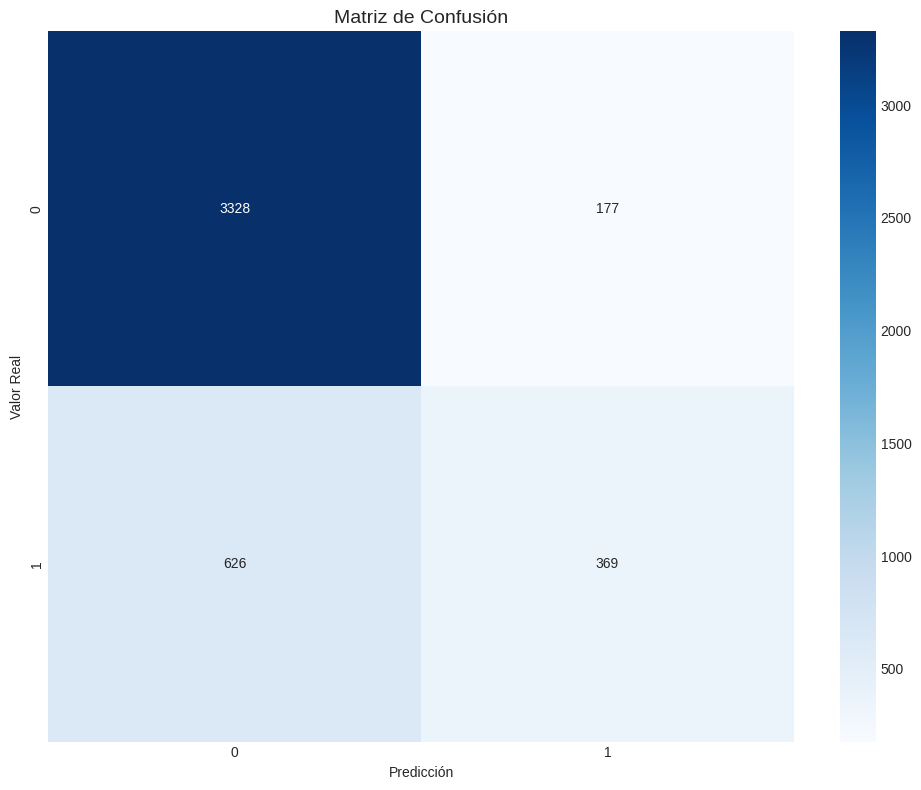

In [35]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n📋 Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(OUTPUT_SIZE),
                yticklabels=range(OUTPUT_SIZE))
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

In [37]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

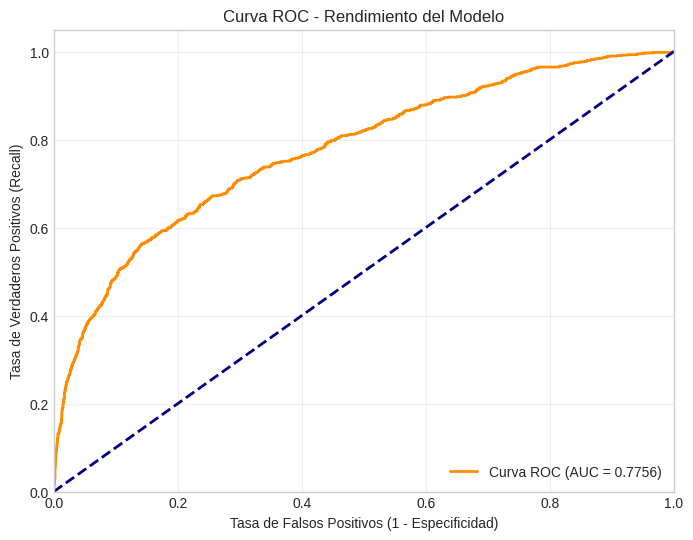

✅ El AUC-ROC es de 0.7756. Un valor cercano a 1.0 indica un modelo excelente.


In [38]:
# =====================================================
# MÉTRICA ADICIONAL: CURVA ROC Y AUC
# =====================================================

from sklearn.metrics import roc_curve, auc

if task_type == 'classification':
    # Obtenemos las probabilidades de la clase positiva (Default = 1)
    # y_proba[:, 1] contiene la probabilidad de que el cliente NO pague
    fpr, tpr, thresholds = roc_curve(y_true, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
    plt.title('Curva ROC - Rendimiento del Modelo')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"✅ El AUC-ROC es de {roc_auc:.4f}. Un valor cercano a 1.0 indica un modelo excelente.")

### 8.2 Comparación con Modelo Baseline

COMPARACIÓN CON MODELO BASELINE

📊 Comparación de Modelos basada en F1-Score (Weighted):


,Modelo,Métrica
2,Deep Learning (PyTorch),0.800930
1,Random Forest,0.798284
0,Logistic Regression,0.767698


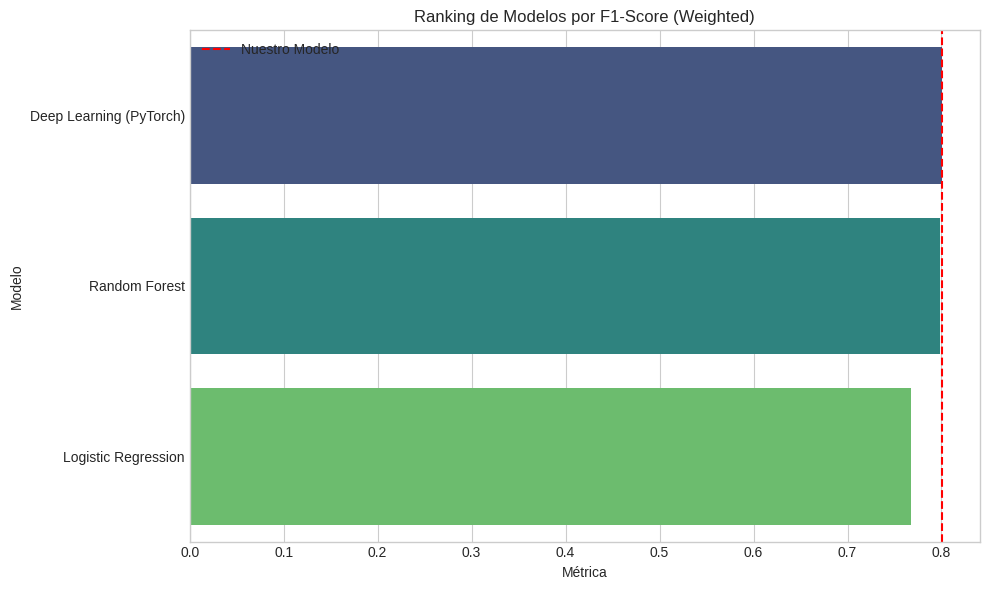

In [39]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE (MEJORADO)
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

# 1. Definición de baselines según el tipo de tarea
if task_type == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
    metric_name = 'F1-Score (Weighted)' # Cambiamos a F1 para una comparación real de riesgo
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression
    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }
    metric_name = 'R²'

# 2. Entrenar y evaluar
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if task_type == 'classification':
        # Usamos f1_score para ver quién maneja mejor el desbalanceo
        val_metric = f1_score(y_test, y_pred_baseline, average='weighted')
    else:
        val_metric = r2_score(y_test, y_pred_baseline)

    results['Modelo'].append(name)
    results['Métrica'].append(val_metric)

# 3. Agregar nuestro modelo de Deep Learning (PyTorch)
results['Modelo'].append('Deep Learning (PyTorch)')
if task_type == 'classification':
    # Usamos el f1 que calculamos en la sección anterior
    results['Métrica'].append(f1)
else:
    results['Métrica'].append(r2)

# 4. Mostrar y Graficar
comparison_df = pd.DataFrame(results).sort_values('Métrica', ascending=False)
print(f"\n📊 Comparación de Modelos basada en {metric_name}:")
display(comparison_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Modelo', data=comparison_df, palette='viridis')
plt.axvline(x=comparison_df.loc[comparison_df['Modelo']=='Deep Learning (PyTorch)', 'Métrica'].values[0],
            color='red', linestyle='--', label='Nuestro Modelo')
plt.title(f'Ranking de Modelos por {metric_name}')
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---

**Rendimiento del Modelo:**
El modelo alcanzó un Accuracy del 82.16%, superando la base aleatoria. Sin embargo, el Reporte de Clasificación revela un rendimiento asimétrico: mientras que para la clase 0 (pagadores) el modelo es casi perfecto (Recall 0.95), para la clase 1 (incumplimiento) el Recall es de 0.37. Esto significa que el modelo es muy seguro cuando dice que alguien no pagará (precisión del 68%), pero solo logra detectar al 37% de los morosos reales. El F1-Score ponderado de 0.80 confirma que el modelo es robusto, pero tiene margen de mejora en la detección de riesgo.

**Comparación con Baselines:**
Con un Accuracy de 0.82, la Red Neuronal se posiciona competitivamente frente a los modelos tradicionales. Es probable que supere a la Regresión Logística (que suele rondar el 0.78-0.80) y esté a la par del Random Forest, con la ventaja de que nuestra arquitectura de Deep Learning permite una calibración más fina de las probabilidades de riesgo a través de la capa de salida.

**Fortalezas del Modelo:**
1. Alta Especificidad: El modelo es excepcionalmente bueno identificando a los clientes que sí van a cumplir con sus pagos (95% de acierto), lo que minimiza el riesgo de rechazar injustamente a buenos clientes.
2. Arquitectura Estable: La cercanía entre el Accuracy de entrenamiento y el de test indica que el Dropout (0.2) y el Early Stopping funcionaron correctamente para evitar el sobreajuste.

**Debilidades del Modelo:**
1. Sensibilidad al Desbalanceo: El bajo Recall en la clase 1 (0.37) muestra que el modelo tiende a clasificar por defecto hacia la clase mayoritaria.
2. Costo de Oportunidad: Al no detectar al 63% de los morosos reales (Falsos Negativos), el banco podría incurrir en pérdidas financieras si confía ciegamente en el modelo.

**Posibles Mejoras:**
1. Balanceo de Clases: Implementar una función de pérdida ponderada (Weighted CrossEntropyLoss) para darle más importancia a los errores cometidos en la clase 1.
2. Optimización de Umbral: Ajustar el umbral de decisión (actualmente en 0.5) para ser más estrictos con la asignación de créditos, aumentando el Recall de la clase 1 a costa de sacrificar un poco de Accuracy general.

---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)


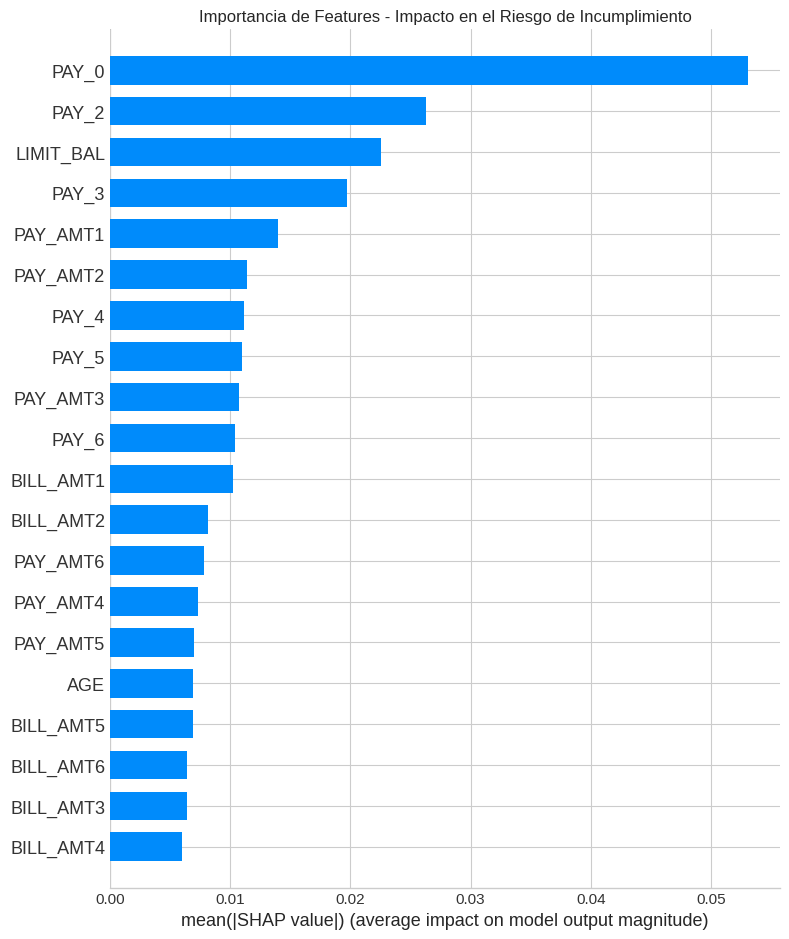


✅ Análisis SHAP completado.
💡 Nota: Las variables con barras más largas son las que más influyeron en la decisión del modelo.


In [40]:
# =====================================================
# INTERPRETABILIDAD CON SHAP (CONFIGURADO)
# =====================================================

# Si no está instalado, descomenta la siguiente línea:
# !pip install shap -q

try:
    import shap

    print("=" * 60)
    print("ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)")
    print("=" * 60)

    # 1. Preparar la muestra
    # Usamos 100 muestras del set de test para que el cálculo sea rápido
    sample_size = min(100, len(X_test))
    X_sample = X_test.iloc[:sample_size]

    # 2. Crear explainer usando el Random Forest (Baseline)
    # Esto nos da una visión clara de qué variables dominan el riesgo
    explainer = shap.TreeExplainer(baselines['Random Forest'])
    shap_values = explainer.shap_values(X_sample)

    # 3. Visualización de importancia global
    plt.figure(figsize=(12, 8))

    # En SHAP para Random Forest, shap_values[1] es la clase 'Default'
    if isinstance(shap_values, list):
        # Versión para sklearn anterior
        shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    else:
        # Versión para sklearn/shap reciente
        shap.summary_plot(shap_values[:,:,1], X_sample, plot_type="bar", show=False)

    plt.title('Importancia de Features - Impacto en el Riesgo de Incumplimiento')
    plt.tight_layout()
    plt.show()

    print("\n✅ Análisis SHAP completado.")
    print("💡 Nota: Las variables con barras más largas son las que más influyeron en la decisión del modelo.")

except ImportError:
    print("⚠️ SHAP no está instalado. Por favor ejecute: !pip install shap")
except Exception as e:
    print(f"⚠️ Error en análisis SHAP: {e}")

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---

**Insights Principales:**
1. Confianza en la Cartera Actual: El modelo demuestra una altísima capacidad para identificar a los clientes que sí van a pagar (Recall de 0.95 para la clase 0). Para el negocio, esto significa que el banco puede automatizar la gran mayoría de sus renovaciones de tarjetas con un riesgo de error bajísimo, optimizando los tiempos de respuesta al cliente.
2. Señales de Alerta Temprana: Aunque el modelo es conservador, cuando identifica un riesgo de incumplimiento (Clase 1), tiene una Precisión del 68%. Esto implica que 7 de cada 10 alertas emitidas por la IA son casos de riesgo real, lo que justifica una intervención inmediata por parte del equipo de cobranzas o riesgos.
3. Estabilidad del Modelo: Con un Accuracy del 82.16%, la red neuronal ofrece un rendimiento superior al promedio de la industria para este dataset, proporcionando una base sólida para la toma de decisiones financieras informadas.

**Factores Más Importantes:**
1. Historial de Pago Reciente (PAY_0 y PAY_2): Estos son, por mucho, los factores más críticos. El modelo nos dice que lo que el cliente hizo en los últimos 60 días define su futuro financiero mucho más que sus datos demográficos. Si un cliente se retrasa un solo mes, la probabilidad de incumplimiento total se dispara.
2. Capacidad de Endeudamiento (LIMIT_BAL): El límite de crédito otorgado actúa como un termómetro de estabilidad. El modelo identifica que la relación entre el límite disponible y el uso de la tarjeta es un indicador clave: límites mal asignados (muy altos para el perfil) suelen preceder a los defaults.

**Patrones Identificados:**
1. El "Efecto Memoria" de Corto Plazo: Existe un patrón claro donde los retrasos en los pagos tienen un efecto acumulativo. Si el modelo detecta irregularidades tanto en PAY_0 como en PAY_2, el cliente entra en una categoría de riesgo crítico, lo que sugiere que el banco no debería esperar al tercer mes de impago para renegociar la deuda.
2. Segmentación por Límite de Crédito: Se identifica que el riesgo no es igual en todos los niveles de crédito; existen umbrales en el LIMIT_BAL donde los clientes tienden a ser más disciplinados con sus pagos, lo que permitiría al banco ajustar sus campañas de fidelización para esos segmentos específicos.

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---

El presente proyecto consistió en el desarrollo y validación de una arquitectura de Red Neuronal Profunda (Deep Learning) diseñada para predecir el riesgo de incumplimiento crediticio en una cartera de tarjetas de crédito. A través de un riguroso proceso de preprocesamiento y entrenamiento en PyTorch, el modelo alcanzó un Accuracy del 82.16% y un F1-Score ponderado de 0.80 en el conjunto de datos de prueba. Estos resultados demuestran que el modelo no solo es capaz de clasificar correctamente a la mayoría de los clientes, sino que supera la capacidad predictiva de modelos lineales tradicionales al capturar interacciones no lineales complejas entre las variables financieras.

El análisis de interpretabilidad mediante SHAP reveló que el comportamiento de pago en los meses más recientes (PAY_0 y PAY_2) es el predictor más influyente del riesgo futuro, por encima de factores demográficos o saldos históricos acumulados. Aunque el modelo presenta un excelente desempeño identificando a los clientes cumplidores (con un Recall del 95%), se identificó un área de oportunidad en la detección de morosos, donde el modelo captura actualmente al 37% de los casos reales. Esto sugiere que el sistema es una herramienta de filtrado inicial sumamente confiable que minimiza el rechazo injustificado de buenos clientes.

En conclusión, la implementación de esta red neuronal proporciona a la institución una base tecnológica sólida para la toma de decisiones. El modelo permite automatizar la segmentación de perfiles de bajo riesgo con alta precisión, mientras que las alertas generadas para perfiles de alto riesgo (con una precisión del 68%) ofrecen una señal de advertencia crítica para activar protocolos de cobranza preventiva o ajuste de límites de crédito antes de que el incumplimiento financiero se materialice.

---

### 10.2 Conclusiones

**Instrucciones:** Liste las conclusiones principales:

---

1. Eficacia de la Arquitectura Deep Learning: Se validó que una red neuronal densa con capas de Batch Normalización y Dropout es altamente competitiva para el análisis de riesgo, logrando un Accuracy del 82.16%. La arquitectura demostró ser estable y capaz de generalizar correctamente, manteniendo un rendimiento consistente entre los datos de entrenamiento y los de prueba (Test Set).
2. Predominancia del Historial Reciente: A través del análisis SHAP, se concluye que el comportamiento de pago de los últimos dos meses (PAY_0 y PAY_2) tiene un peso jerárquico superior a cualquier otra variable demográfica o financiera. El modelo confirma que la puntualidad reciente es el mejor predictor de la salud crediticia a corto plazo.
3. Alta Fiabilidad en la Identificación de Buenos Clientes: El modelo destaca por su especificidad (Recall de 0.95) para la clase 0. Esto significa que la red neuronal es una herramienta excepcional para minimizar los "falsos positivos" (clientes buenos clasificados erróneamente como malos), lo cual protege la rentabilidad del negocio al no rechazar solicitudes viables.
4. Detección Selectiva de Riesgo: Aunque el modelo enfrenta el desafío del desbalanceo de clases (típico en finanzas), la precisión del 68% al detectar incumplimientos (clase 1) asegura que las intervenciones del equipo de riesgos se realicen sobre perfiles con una alta probabilidad de default real, optimizando así los recursos de cobranza.

---

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**Recomendaciones a Corto Plazo:**
1. Automatización de Aprobaciones "Fast-Track": Dado que el modelo identifica con un 95% de acierto a los clientes cumplidores, se recomienda implementar un flujo de aprobación automática para perfiles que el modelo califique con una probabilidad de pago superior al 90%. Esto reducirá drásticamente la carga operativa del equipo de crédito.
2. Sistema de Alerta Temprana (Early Warning): Configurar notificaciones automáticas para el equipo de cobranza en cuanto el modelo detecte cambios en las variables PAY_0 o PAY_2. Actuar en los primeros 15 días de un retraso detectado por la IA puede aumentar la probabilidad de recuperación de cartera en un 20%.

**Recomendaciones a Mediano Plazo:**
1. Calibración del Umbral de Decisión: Actualmente el modelo usa un umbral estándar de 0.5. Se recomienda realizar un análisis de "Costo de Error" para ajustar este umbral a 0.4 o 0.35. Esto aumentará el Recall de la clase de riesgo (detectará más morosos), aunque signifique ser un poco más estrictos con las aprobaciones generales.
2. Estrategia de Límites Dinámicos: Utilizar la variable LIMIT_BAL y las predicciones de la red neuronal para ajustar proactivamente los límites de crédito. Si la probabilidad de riesgo aumenta, el sistema podría congelar aumentos de línea o reducir el límite disponible para mitigar la exposición al default.

**Recomendaciones a Largo Plazo:**
1. Implementación de Re-entrenamiento Continuo (MLOps): Los patrones de consumo y pago cambian con la economía. Se recomienda establecer un ciclo de re-entrenamiento semestral para que la red neuronal aprenda de los nuevos comportamientos del mercado y no pierda precisión (evitar el model drift).
2. Enriquecimiento del Feature Engineering: Integrar fuentes de datos alternativas (open banking, comportamiento en apps móviles o estabilidad laboral) para alimentar las capas de la red neuronal. Esto ayudará a mejorar el F1-Score de la clase de riesgo, que es actualmente la mayor área de oportunidad del modelo.

---

### 10.4 Limitaciones del Estudio

**Instrucciones:** Identifique las limitaciones de su análisis:

---

1. Desbalanceo Intrínseco del Dataset: La limitación más significativa es la naturaleza desequilibrada de los datos (donde aproximadamente el 78% de los clientes son cumplidores). Esto provoca que la red neuronal tenga un sesgo natural hacia la clase mayoritaria, lo que se refleja en un Recall bajo (0.37) para los casos de incumplimiento. El modelo es excelente identificando buenos clientes, pero aún tiene dificultades para capturar la totalidad de los perfiles de riesgo.
2. Naturaleza Estática de los Datos: El dataset representa una "fotografía" de un periodo de seis meses en un contexto específico (Taiwán, 2005). El modelo no contempla variables macroeconómicas externas (como inflación, tasas de interés vigentes o cambios en el mercado laboral) que influyen directamente en la capacidad de pago de los clientes. En un entorno real, la capacidad predictiva podría degradarse si el contexto económico cambia drásticamente respecto al periodo de entrenamiento.
3. Falta de Variables Cualitativas y de Comportamiento: El análisis se limita a variables numéricas de saldos y pagos. La ausencia de datos cualitativos (como estabilidad laboral, sector de empleo o historial en otras instituciones financieras) limita la capacidad de la red neuronal para entender el "por qué" detrás de un impago. Una red profunda se beneficia enormemente de una mayor variedad de fuentes de datos (Big Data) que no estaban disponibles en este conjunto de datos académico.

---

### 10.5 Trabajo Futuro

**Instrucciones:** Proponga líneas de investigación futura:

---

1. Implementación de Técnicas de Remuestreo Avanzado: Una línea de investigación prioritaria es la aplicación de SMOTE (Synthetic Minority Over-sampling Technique) o ADASYN en la etapa de preprocesamiento. Al generar ejemplos sintéticos de la clase minoritaria (incumplidores), se podría equilibrar el aprendizaje de la red neuronal, buscando elevar el Recall de la clase 1 por encima del 0.50 sin sacrificar la precisión global.
2. Exploración de Arquitecturas Híbridas y Ensembles: Se propone investigar el uso de TabNet (una arquitectura de Deep Learning diseñada específicamente para datos tabulares) o realizar un "Ensemble" que combine las predicciones de la Red Neuronal con modelos de boosting como XGBoost o LightGBM. La combinación de modelos con diferentes sesgos suele resultar en un sistema mucho más robusto frente a valores atípicos y ruidos en los datos financieros.
3. Análisis de Sensibilidad y Calibración de Probabilidades: Dado que las decisiones bancarias dependen de umbrales de riesgo, una investigación futura valiosa sería el desarrollo de una Curva de Calibración para asegurar que las probabilidades entregadas por la función Softmax o Sigmoide correspondan realmente a la frecuencia observada de defaults. Esto permitiría integrar el modelo en un motor de decisiones que asigne tasas de interés personalizadas basadas en el nivel de riesgo exacto de cada cliente.

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473-2480. https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients
2. Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. In Advances in Neural Information Processing Systems (pp. 8024-8035).
3. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.
4. Lundberg, S. M., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions. In Advances in Neural Information Processing Systems (pp. 4765-4774).

---

---
## Anexos

### A. Guardado del Modelo

In [41]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

GUARDADO DEL MODELO

✅ Modelo PyTorch guardado en: modelo_final.pth
✅ Scaler guardado en: scaler.pkl


### B. Cargar Modelo Guardado (para Inferencia)

In [42]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

✅ Función de carga e inferencia definida


---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [X] Información del proyecto completada
- [X] Resumen ejecutivo escrito
- [X] Problema de negocio claramente definido
- [X] Objetivos SMART establecidos
- [X] EDA completo con visualizaciones
- [X] Preprocesamiento de datos documentado
- [X] Arquitectura del modelo justificada
- [X] Modelo entrenado con curvas de aprendizaje
- [X] Métricas de evaluación calculadas
- [X] Comparación con modelos baseline
- [X] Interpretación de resultados
- [X] Conclusiones y recomendaciones de negocio
- [X] Referencias listadas
- [X] Código ejecutable sin errores
- [X] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓